In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

In [ ]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)


In [ ]:
df['Geography'].value_counts()


,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
df['Gender'].value_counts()


,count
Gender,
Male,5457
Female,4543


In [ ]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)


In [ ]:
df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
model = Sequential()
model.add(Dense(5,activation="sigmoid",input_dim=11))
model.add(Dense(10,activation="sigmoid"))
model.add(Dense(1,activation="sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
history = model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6930 - loss: 0.6397 - val_accuracy: 0.7969 - val_loss: 0.5345
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7935 - loss: 0.5281 - val_accuracy: 0.7969 - val_loss: 0.5116
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8017 - loss: 0.5034 - val_accuracy: 0.7969 - val_loss: 0.5082
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7947 - loss: 0.5093 - val_accuracy: 0.7969 - val_loss: 0.5073
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7896 - loss: 0.5155 - val_accuracy: 0.7969 - val_loss: 0.5070
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8001 - loss: 0.5021 - val_accuracy: 0.7969 - val_loss: 0.5069
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - loss: 0.4997 - val_accuracy: 0.7969 - val_loss: 0.5068
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8009 - loss: 0.5005 - val_accu

In [ ]:
model.get_weights()[0]

array([[ 0.29962403, -0.1294329 ,  0.07731131,  0.27779442,  0.25982258],
       [ 0.44985908, -0.20525922, -0.56533533, -0.34826007,  0.00474715],
       [-0.05479043, -0.19369932,  0.5538704 ,  0.12272328, -0.5588447 ],
       [-0.4149419 ,  0.43926185,  0.22578236,  0.55740076, -0.56676716],
       [ 0.06071284,  0.56500477, -0.4990188 ,  0.37064278, -0.10363966],
       [-0.23322862, -0.08025709,  0.11990781, -0.04105399,  0.5650924 ],
       [ 0.43498582, -0.4190066 ,  0.13066089,  0.02711947,  0.60934514],
       [-0.5934212 ,  0.35427165, -0.47596616, -0.40900242, -0.5966204 ],
       [ 0.15229696, -0.51741827,  0.22181304,  0.21290036,  0.05478436],
       [ 0.19275123, -0.21234891,  0.11574388,  0.13553864, -0.5183376 ],
       [-0.06005599, -0.3475696 , -0.19082214, -0.38755155, -0.58085567]],
      dtype=float32)

In [ ]:
model.get_weights()

[array([[ 0.29962403, -0.1294329 ,  0.07731131,  0.27779442,  0.25982258],
        [ 0.44985908, -0.20525922, -0.56533533, -0.34826007,  0.00474715],
        [-0.05479043, -0.19369932,  0.5538704 ,  0.12272328, -0.5588447 ],
        [-0.4149419 ,  0.43926185,  0.22578236,  0.55740076, -0.56676716],
        [ 0.06071284,  0.56500477, -0.4990188 ,  0.37064278, -0.10363966],
        [-0.23322862, -0.08025709,  0.11990781, -0.04105399,  0.5650924 ],
        [ 0.43498582, -0.4190066 ,  0.13066089,  0.02711947,  0.60934514],
        [-0.5934212 ,  0.35427165, -0.47596616, -0.40900242, -0.5966204 ],
        [ 0.15229696, -0.51741827,  0.22181304,  0.21290036,  0.05478436],
        [ 0.19275123, -0.21234891,  0.11574388,  0.13553864, -0.5183376 ],
        [-0.06005599, -0.3475696 , -0.19082214, -0.38755155, -0.58085567]],
       dtype=float32),
 array([ 1.04167275e-05,  4.99225393e-07, -3.10521813e-07,  2.62965023e-06,
         2.81610486e-08], dtype=float32),
 array([[ 0.5820613 ,  0.49185884

In [ ]:
model.get_weights()[0].shape

(11, 5)

In [ ]:
model.get_weights()[1]

array([ 1.04167275e-05,  4.99225393e-07, -3.10521813e-07,  2.62965023e-06,
        2.81610486e-08], dtype=float32)

In [ ]:
model.get_weights()[1].shape

(5,)

In [ ]:
model.get_weights()[2]

array([[ 0.5820613 ,  0.49185884,  0.23759681,  0.62179863, -0.03449311,
         0.3970007 , -0.39959976,  0.0538739 , -0.39203513,  0.5974248 ],
       [ 0.08371861,  0.17317462, -0.47137594,  0.08118157,  0.5062401 ,
        -0.03865163, -0.20907201,  0.16785823, -0.04178862, -0.5514088 ],
       [-0.45938537,  0.21094003, -0.26276582, -0.05105843, -0.5581207 ,
        -0.4587676 ,  0.30405554,  0.37773672, -0.18107967,  0.53275114],
       [-0.32225877,  0.15674989, -0.19416076,  0.18051487,  0.23680621,
         0.05277909,  0.00200591, -0.08827341, -0.4617221 ,  0.49521434],
       [ 0.2628888 ,  0.09779086,  0.5430384 , -0.5766112 ,  0.4456279 ,
         0.38531864,  0.46821532,  0.07110236,  0.29405278, -0.53653467]],
      dtype=float32)

In [ ]:
model.get_weights()[2].shape

(5, 10)

In [ ]:
y_pred = model.predict(X_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [ ]:
y_pred

array([[0.19004048],
       [0.2130417 ],
       [0.2130417 ],
       ...,
       [0.2130417 ],
       [0.22874641],
       [0.19004048]], dtype=float32)

In [ ]:
y_pred.shape

(2000, 1)

In [ ]:
y_pred = y_pred.argmax(axis=-1)
#[0.7,0.9,0.93]

In [ ]:
pd.Series(y_pred).value_counts()

,count
0,2000


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7975

In [ ]:
model.optimizer.get_config()["learning_rate"]

0.009999999776482582

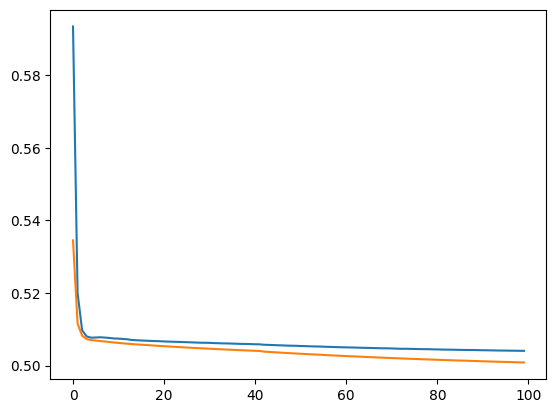

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

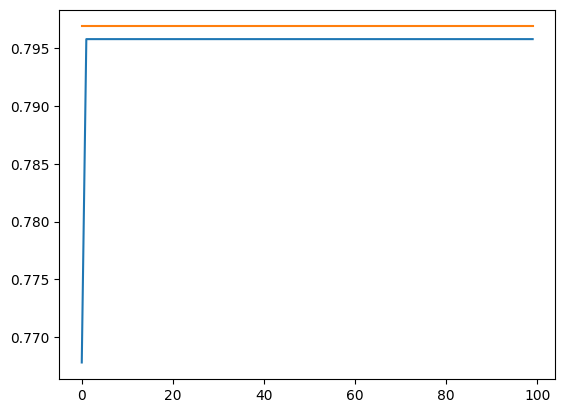

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
y_pred = model.predict(X_test)
y_pred_binary = (y_pred >= 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
y_pred_binary

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_binary)

0.7975

# Vanshing Gradient

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [ ]:
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

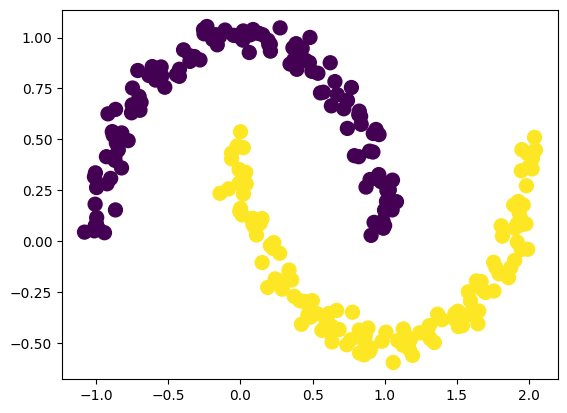

In [ ]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [ ]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [ ]:
model.get_weights()[0]

array([[-0.3982584 , -0.56555307, -0.13066751,  0.02051389, -0.03149855,
         0.28892726, -0.06949711, -0.3918922 , -0.17968416, -0.34086365],
       [ 0.43923813,  0.21378046,  0.01824349, -0.13711232,  0.09496105,
        -0.19931549, -0.61038804, -0.5280149 , -0.17896682,  0.5833425 ]],
      dtype=float32)

In [ ]:
old_weights = model.get_weights()[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5382 - loss: 0.6891  
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5101 - loss: 0.6968 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5231 - loss: 0.6921 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5099 - loss: 0.6941 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4867 - loss: 0.6989 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4852 - loss: 0.6981 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5044 - loss: 0.6933 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5254 - loss: 0.6878 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5118 - loss: 0.6908 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5524 - loss: 0.6821 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4998 - loss: 0.6917 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4989 - lo

In [ ]:
new_weights = model.get_weights()[0]

In [ ]:
new_weights

array([[-0.35261187, -0.62126607, -0.15280041, -0.03541732,  0.01235551,
         0.31540698, -0.01744497, -0.39021522, -0.17365955, -0.3604989 ],
       [ 0.4027753 ,  0.26387045,  0.03484974, -0.09584458,  0.06208406,
        -0.2203235 , -0.64734447, -0.5295554 , -0.18365528,  0.5987965 ]],
      dtype=float32)

In [ ]:
model.optimizer.get_config()["learning_rate"]

0.009999999776482582

In [ ]:
gradient = (old_weights - new_weights)/ model.optimizer.get_config()["learning_rate"]
gradient

array([[-4.564652  ,  5.5713    ,  2.2132905 ,  5.593121  , -4.385406  ,
        -2.647972  , -5.2052135 , -0.16769767, -0.6024614 ,  1.963526  ],
       [ 3.6462843 , -5.0089984 , -1.6606253 , -4.126774  ,  3.2876987 ,
         2.1008015 ,  3.695643  ,  0.1540482 ,  0.46884567, -1.5453994 ]],
      dtype=float32)

In [ ]:
percent_change = abs(100*(old_weights - new_weights)/ old_weights)
percent_change

array([[ 11.461534  ,   9.851064  ,  16.938337  , 272.65042   ,
        139.22565   ,   9.16484   ,  74.89827   ,   0.42791787,
          3.352891  ,   5.760444  ],
       [  8.301384  ,  23.43057   ,  91.02563   ,  30.097761  ,
         34.62155   ,  10.540081  ,   6.0545797 ,   0.29174975,
          2.6197352 ,   2.6492145 ]], dtype=float32)

# Relu

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [ ]:
old_weights = model.get_weights()[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4699 - loss: 0.6932  
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5261 - loss: 0.6930 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4754 - loss: 0.6932 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5203 - loss: 0.6930 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5226 - loss: 0.6930 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4943 - loss: 0.6930 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5186 - loss: 0.6930 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4912 - loss: 0.6931 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5292 - loss: 0.6929 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4785 - loss: 0.6931 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4923 - loss: 0.6931 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5267 - lo

In [ ]:
new_weights = model.get_weights()[0]

In [ ]:
model.optimizer.get_config()["learning_rate"]

0.009999999776482582

In [ ]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [ ]:
percent_change

array([[14.960868  ,  1.9523865 ,  8.643688  ,  1.5698301 ,  1.097711  ,
         1.646945  ,  4.386154  , 11.475638  ,  1.0296423 ,  1.9985098 ],
       [ 0.49497762,  0.8876258 ,  2.7529614 ,  0.18859693,  0.7264849 ,
         0.2962728 ,  0.26473185,  0.83789396,  0.21377176,  0.06568152]],
      dtype=float32)

In [ ]:
gradient

array([[ 11.091008  ,  -4.215747  ,   6.926618  ,  -2.0530074 ,
         -2.372831  ,   8.38542   ,   3.881499  , -19.966825  ,
          5.8575864 ,  -3.2645462 ],
       [ -1.9504129 ,  -2.1435916 , -12.918799  ,  -1.2083054 ,
         -1.1796504 ,  -0.54706633,  -0.97018474,  -3.064066  ,
         -1.4175771 ,  -0.3764629 ]], dtype=float32)

In [ ]:
old_weights

array([[ 0.07413346,  0.2159279 , -0.08013499,  0.13077897, -0.21616173,
         0.50914997, -0.08849436,  0.17399317, -0.5688953 , -0.16334903],
       [-0.39404064, -0.24149722,  0.46926922, -0.6406813 ,  0.16237783,
         0.18464953, -0.3664783 , -0.36568663, -0.6631265 , -0.5731641 ]],
      dtype=float32)

In [ ]:
new_weights

array([[ 0.06304245,  0.22014365, -0.08706161,  0.13283198, -0.2137889 ,
         0.50076455, -0.09237586,  0.19396   , -0.57475287, -0.16008449],
       [-0.39209023, -0.23935363,  0.48218802, -0.639473  ,  0.16355748,
         0.1851966 , -0.3655081 , -0.36262256, -0.66170895, -0.57278764]],
      dtype=float32)